# Lesson C - LangGraph Fundamentals (Explicit Graphs)
**Presented by:** Sharad Rajore | **Organization:** Zensar Technologies

---

### Learning Objectives
1. **See the Shift:** Move from `create_agent()` to an explicit LangGraph workflow.
2. **Build the Core Pieces:** Understand `State`, `Nodes`, `Edges`, and `Conditional Edges`.
3. **Add Tools:** Route from the assistant to a `ToolNode` only when the model asks for a tool.
4. **Add Memory:** Use `MemorySaver` + `thread_id` with an explicit graph.
5. **Prepare for MCP:** See where MCP-provided tools will plug into the same graph later.

### The Core Idea
LangGraph lets us model an agent as a **state machine**.

Instead of saying, "agent, figure everything out," we describe the workflow:

| LangGraph Concept | Simple Meaning | In this lesson |
|---|---|---|
| `State` | Shared data moving through the graph | `messages` |
| `Node` | A function that reads/writes state | call the LLM, run tools |
| `Edge` | The next step | start -> assistant |
| Conditional edge | A decision point | tools needed or final answer? |
| Checkpointer | Saved graph state | conversation memory by `thread_id` |

---

**Where this fits in the course:**
- Lesson A: Short-term memory with `checkpointer` + `thread_id`
- Lesson B: Long-term memory with `store` + `user_id`
- **Lesson C: Explicit LangGraph workflows**
- Next: MCP tools plugged into LangGraph

## Setup

In [1]:
from dotenv import load_dotenv
load_dotenv()

import importlib.metadata as metadata
import langchain

print(f"LangChain: {langchain.__version__}")
print(f"LangGraph: {metadata.version('langgraph')}")

LangChain: 1.3.9
LangGraph: 1.2.5


In [2]:
from langchain_ollama import ChatOllama

llm = ChatOllama(model="gpt-oss:120b-cloud", temperature=0)

# -- Alternatively, use Groq --------------------------------------------------
# from langchain_groq import ChatGroq
# llm = ChatGroq(model="llama-3.3-70b-versatile")
# ------------------------------------------------------------------------------

print("LLM ready.")

LLM ready.


In [4]:
from langchain_core.tools import tool

# Reusing familiar local tools from previous lessons
@tool
def get_weather(city: str) -> str:
    """Returns the current weather for a given city."""
    return f"The weather in {city} is sunny with a high of 28C."

@tool
def get_stock_price(ticker: str) -> str:
    """Returns the current stock price for a given ticker symbol.
    Use 'ZENSAR' for Zensar Technologies, 'GOOGL' for Google."""
    prices = {"ZENSAR": "527.90 INR", "GOOGL": "175.00 USD"}
    return prices.get(ticker.upper(), f"Unknown ticker: {ticker}")

TOOLS = [get_weather, get_stock_price]
print("Tools ready: get_weather, get_stock_price")

Tools ready: get_weather, get_stock_price


---
## Part 1: What `create_agent()` Was Hiding

In earlier notebooks we used `create_agent()` because it is perfect for getting started quickly.

Under the hood, it is already building a graph-like loop:

```
User message -> Assistant -> Tool? -> Assistant -> Final answer
```

Now we will build that loop ourselves, one piece at a time.

In [4]:
from langchain.agents import create_agent

quick_agent = create_agent(
    model=llm,
    tools=TOOLS,
    system_prompt="You are a helpful assistant. Use tools when needed.",
)

response = quick_agent.invoke({
    "messages": [("user", "What is the weather in Pune and the Zensar stock price?")]
})

print(response["messages"][-1].content)
print()
print("create_agent() is convenient, but the workflow is mostly hidden from us.")

**Weather in Pune:** Sunny, high of **28 °C**.  

**Zensar Technologies (ZENSAR) stock price:** **₹ 464.00**.

create_agent() is convenient, but the workflow is mostly hidden from us.


### Why build the graph explicitly?

Explicit LangGraph gives us control over workflow shape:

| Need | Why explicit graph helps |
|---|---|
| Tool approval | Pause before running risky tools |
| Custom routing | Send finance questions one way, support questions another way |
| Debugging | Inspect every node and state update |
| Memory | Add checkpointers at graph compile time |
| MCP | Treat MCP server capabilities as tools in the same loop |

---
## Part 2: The Smallest Useful LangGraph

A graph needs three things:

1. A **state schema**
2. One or more **nodes**
3. **Edges** connecting the nodes

We start with the simplest graph: one assistant node, no tools.

In [5]:
from typing import Annotated, TypedDict

from langchain_core.messages import AnyMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    # add_messages appends new messages instead of replacing the whole list
    messages: Annotated[list[AnyMessage], add_messages]

print("AgentState ready.")

AgentState ready.


In [6]:
def call_llm(state: AgentState) -> dict:
    """One graph node: call the LLM using the current messages."""
    response = llm.invoke(state["messages"])
    return {"messages": [response]}



In [8]:
# Build the graph
simple_builder = StateGraph(AgentState)
simple_builder.add_node("assistant", call_llm)


simple_builder.add_edge(START, "assistant")
simple_builder.add_edge("assistant", END)

simple_graph = simple_builder.compile()
print("Simple graph compiled: START -> assistant -> END")

Simple graph compiled: START -> assistant -> END


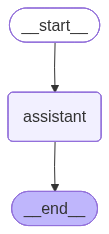

In [9]:
simple_graph

In [10]:
simple_result = simple_graph.invoke({
    "messages": [("user", "Explain LangGraph in one sentence.")]
})

print(simple_result["messages"][-1].content)
print()
print(f"Messages in final state: {len(simple_result['messages'])}")

LangGraph is a Python framework that lets you compose, orchestrate, and manage LLM‑powered agents and workflows as reusable, stateful graph structures.

Messages in final state: 2


### What happened to state?

The graph started with one human message.

The `assistant` node returned one AI message.

Because we used `add_messages`, LangGraph **appended** the AI message to the existing state instead of overwriting it.

In [11]:
for i, msg in enumerate(simple_result["messages"], 1):
    role = msg.__class__.__name__.replace("Message", "")
    text = str(msg.content)
    text = text[:90] + "..." if len(text) > 90 else text
    print(f"[{i}] {role}: {text}")

[1] Human: Explain LangGraph in one sentence.
[2] AI: LangGraph is a Python framework that lets you compose, orchestrate, and manage LLM‑powered...


---
## Part 3: State, Nodes, Edges - The Mental Model

Think of every node as a normal Python function:

```
def node_name(state):
    # read current state
    # do one useful thing
    # return only the state update
    return {"messages": [new_message]}
```

LangGraph handles the state merge after each node.

That means your node functions can stay small and testable.

In [10]:
print(simple_graph.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	assistant(assistant)
	__end__([<p>__end__</p>]):::last
	__start__ --> assistant;
	assistant --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



The Mermaid diagram above is useful in class because participants can literally see the workflow.

For this graph, there is no decision-making yet:

```
START -> assistant -> END
```

Next we add a decision: **does the assistant want to call a tool?**

---
## Part 4: Add Tools with a Conditional Edge

The agent loop has two important steps:

1. The assistant decides whether a tool is needed.
2. If there are tool calls, the graph routes to `tools`; otherwise it stops.

This is where LangGraph starts to feel different from a plain chain.

In [12]:
from langgraph.prebuilt import ToolNode

llm_with_tools = llm.bind_tools(TOOLS)

def assistant(state: AgentState) -> dict:
    """Assistant node: call the model, allowing it to request tools."""
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}


def route_after_assistant(state: AgentState) -> str:
    """Route to tools only when the model produced tool calls."""
    last_message = state["messages"][-1]
    if getattr(last_message, "tool_calls", None):
        return "tools"
    return END

print("assistant node and router ready.")

assistant node and router ready.


In [14]:
tool_builder = StateGraph(AgentState)
tool_builder.add_node("tools", ToolNode(TOOLS))
tool_builder.add_node("assistant", assistant)


tool_builder.add_edge(START, "assistant")
tool_builder.add_conditional_edges(
    "assistant",
    route_after_assistant,
    {
        "tools": "tools",
        END: END,
    },
)
tool_builder.add_edge("tools", "assistant")

tool_graph = tool_builder.compile()
print("Tool graph compiled: assistant <-> tools, with a conditional exit to END")

Tool graph compiled: assistant <-> tools, with a conditional exit to END


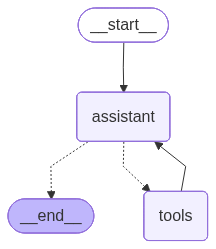

In [15]:
tool_graph

In [12]:
print(tool_graph.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	assistant(assistant)
	tools(tools)
	__end__([<p>__end__</p>]):::last
	__start__ --> assistant;
	assistant -.-> __end__;
	assistant -.-> tools;
	tools --> assistant;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [15]:
tool_result = tool_graph.invoke({
    "messages": [("user", "What is the weather in Pune and the Zensar stock price?")]
})

print("Final answer:")
print(tool_result["messages"][-1].content)


Final answer:
**Current Weather in Pune:**  
- Sunny  
- High temperature: **28 °C**  

**Zensar Technologies (ZENSAR) Stock Price:**  
- **527.90 INR** (current price)

*Note: Stock prices can fluctuate throughout the trading day, so you may want to check again closer to the time you plan to act on this information.*


In [16]:
print()
print("Messages captured in graph state:")
for i, msg in enumerate(tool_result["messages"], 1):
    role = msg.__class__.__name__.replace("Message", "")
    text = str(msg.content)
    text = text[:100] + "..." if len(text) > 100 else text
    print(f"[{i}] {role}: {text}")


Messages captured in graph state:
[1] Human: What is the weather in Pune and the Zensar stock price?
[2] AI: 
[3] Tool: The weather in Pune is sunny with a high of 28C.
[4] AI: 
[5] Tool: 527.90 INR
[6] AI: **Current Weather in Pune:**  
- Sunny  
- High temperature: **28 °C**  

**Zensar Technologies (ZEN...


### What just happened?

The graph did this loop automatically:

```
User -> assistant
assistant -> tools       # only because the AI message had tool_calls
tools -> assistant       # tool results are now in messages
assistant -> END         # final answer, no more tool calls
```

The important point: **the routing decision is visible in our code.**

---
## Part 5: Same Graph, Now With Memory

Lesson A taught us that memory needs a checkpointer and a `thread_id`.

The same idea works with an explicit graph:

```python
compiled_graph = builder.compile(checkpointer=MemorySaver())
config = {"configurable": {"thread_id": "some_session"}}
```

In [17]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

memory_builder = StateGraph(AgentState)
memory_builder.add_node("assistant", assistant)
memory_builder.add_node("tools", ToolNode(TOOLS))
memory_builder.add_edge(START, "assistant")
memory_builder.add_conditional_edges(
    "assistant",
    route_after_assistant,
    {
        "tools": "tools",
        END: END,
    },
)
memory_builder.add_edge("tools", "assistant")

graph_with_memory = memory_builder.compile(checkpointer=memory)
print("Graph with MemorySaver ready.")

Graph with MemorySaver ready.


In [19]:
config = {"configurable": {"thread_id": "langgraph_session_sharad"}}

In [20]:
print("=" * 60)
print("Turn 1:")
r1 = graph_with_memory.invoke(
    {"messages": [("user", "Hi! My name is Sharad and I work at Zensar in Pune.")]},
    config=config,
)
print(r1["messages"][-1].content)

Turn 1:
Hello Sharad! It’s great to meet you. How can I assist you today?


In [21]:
print()
print("=" * 60)
print("Turn 2:")
r2 = graph_with_memory.invoke(
    {"messages": [("user", "What is my name, where do I work, and what is the weather in Pune?")]},
    config=config,
)
print(r2["messages"][-1].content)
print()
print("Same thread_id -> same conversation state.")


Turn 2:
- **Name:** Sharad  
- **Workplace:** Zensar (Pune)  
- **Weather in Pune:** Sunny with a high of 28 °C.

Same thread_id -> same conversation state.


In [23]:
checkpoint = memory.get(config)

print("Stored messages for 'langgraph_session_sharad':")
print()

if checkpoint:
    stored_messages = checkpoint["channel_values"].get("messages", [])
    for i, msg in enumerate(stored_messages, 1):
        role = msg.__class__.__name__.replace("Message", "")
        text = str(msg.content)
        text = text[:90] + "..." if len(text) > 90 else text
        print(f"[{i}] {role}: {text}")
else:
    print("No checkpoint found.")

Stored messages for 'langgraph_session_sharad':

[1] Human: Hi! My name is Sharad and I work at Zensar in Pune.
[2] AI: Hi Sharad! 👋 Great to meet you. How can I help you today? Whether you’d like to check the ...
[3] Human: What is my name, where do I work, and what is the weather in Pune?
[4] AI: 
[5] Tool: The weather in Pune is sunny with a high of 28C.
[6] AI: Your name is **Sharad**, you work at **Zensar** in **Pune**, and the current weather in Pu...


---
## Part 6: Streaming the Graph

`invoke()` gives the final state.

`stream()` lets you watch nodes run one by one, which is very useful while teaching, debugging, or tracing a production issue.

In [22]:
stream_config = {"configurable": {"thread_id": "stream_demo"}}

for event in graph_with_memory.stream(
    {"messages": [("user", "What is the Zensar stock price?")]},
    config=stream_config,
):
    print(event.keys())
    print(event)
    print("-" * 60)

dict_keys(['assistant'])
{'assistant': {'messages': [AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'gpt-oss:120b', 'created_at': '2026-07-15T10:07:18.49675274Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1603711373, 'load_duration': None, 'prompt_eval_count': 180, 'prompt_eval_duration': None, 'eval_count': 59, 'eval_duration': None, 'logprobs': None, 'model_name': 'gpt-oss:120b', 'model_provider': 'ollama'}, id='lc_run--019f653e-b551-7b82-b2c1-ce8f6561713a-0', tool_calls=[{'name': 'get_stock_price', 'args': {'ticker': 'ZENSAR'}, 'id': 'bee88211-78ec-4469-bc64-b9290b1203ff', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 180, 'output_tokens': 59, 'total_tokens': 239})]}}
------------------------------------------------------------
dict_keys(['tools'])
{'tools': {'messages': [ToolMessage(content='527.90 INR', name='get_stock_price', id='ec724109-ac70-455c-8027-28da71dc5069', tool_call_id='bee88211-78ec-4469-bc64-b9290

### Teaching note

Streaming output is intentionally verbose.

For participants, the key observation is simple: each event is a node update.

That makes LangGraph easier to debug than a hidden agent loop.

---
## Part 7: Where MCP Fits Next

MCP is a standard way to expose external capabilities - files, databases, APIs, tools - to an AI application.

From LangGraph's point of view, MCP tools are still **tools**.

The graph shape does not need to change much:

```
MCP Server -> MCP Client/Adapter -> LangChain Tools -> ToolNode -> Assistant
```

So the graph we built today is the foundation for the MCP lesson.

In [18]:
print("Today: local Python tools")
print("  get_weather, get_stock_price")
print()
print("Next: MCP-provided tools")
print("  filesystem/search/database/etc. exposed by an MCP server")
print()
print("LangGraph sees both as tools in a ToolNode.")

Today: local Python tools
  get_weather, get_stock_price

Next: MCP-provided tools
  filesystem/search/database/etc. exposed by an MCP server

LangGraph sees both as tools in a ToolNode.


---
## Side-by-Side Comparison

| Pattern | What you control | Best use |
|---|---|---|
| `llm.invoke()` | One model call | Simple Q&A |
| `create_agent()` | Tools + prompt + memory settings | Fast agent demos |
| Explicit LangGraph | State, routing, tool loop, memory, interrupts | Real workflows |
| LangGraph + MCP | Same graph, external tools from MCP servers | Enterprise/tool-rich agents |

---
## Summary

### What we learned

**LangGraph is a state machine for agent workflows.**

| Concept | Remember it as |
|---|---|
| `State` | The shared working memory for the graph |
| `Node` | One function that does one step |
| `Edge` | The normal next step |
| Conditional edge | A router / decision point |
| `ToolNode` | Executes model-requested tools |
| `MemorySaver` | Saves graph state per `thread_id` |

### Key concept: visible control flow

With `create_agent()`, the agent loop is convenient but mostly hidden.

With LangGraph, the workflow is explicit:

```
START -> assistant -> tools -> assistant -> END
```

### What's next - MCP

In the MCP lesson, we will replace today's local demo tools with tools exposed by MCP servers.
The graph stays familiar; the tool source becomes more powerful.

---
## Bonus - Mini Support Workflow Demo

This final demo combines the pieces:

- Explicit graph
- Tool routing
- Short-term memory
- One continuous support-style conversation

In [19]:
support_config = {"configurable": {"thread_id": "support_workflow_demo"}}

conversation = [
    "Hello, I'm Rahul from the Mumbai office.",
    "What's the current Zensar stock price?",
    "Also, what's the weather in Pune?",
    "What is my name and which office did I say I am from?",
]

for i, user_msg in enumerate(conversation, 1):
    print(f"{'=' * 60}")
    print(f"Turn {i} - User: {user_msg}")
    response = graph_with_memory.invoke(
        {"messages": [("user", user_msg)]},
        config=support_config,
    )
    print(f"Turn {i} - Agent: {response['messages'][-1].content}")
    print()

Turn 1 - User: Hello, I'm Rahul from the Mumbai office.
Turn 1 - Agent: Hello Rahul! 👋 Great to hear from the Mumbai office. How can I assist you today?

Turn 2 - User: What's the current Zensar stock price?
Turn 2 - Agent: The current Zensar Technologies stock price is **₹464.00**. Let me know if you need any more details!

Turn 3 - User: Also, what's the weather in Pune?
Turn 3 - Agent: In Pune, it’s currently **sunny with a high of 28 °C**. Let me know if you’d like a longer forecast or anything else!

Turn 4 - User: What is my name and which office did I say I am from?
Turn 4 - Agent: Your name is **Rahul**, and you mentioned that you’re from the **Mumbai office**.

